# Calo Clustering Studies

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import sys
import time
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
from edm4hep_utils import load_edm4hep_file, create_truth_clusters
from clustering_metrics import evaluate_clustering, plot_clustering_metrics, adjusted_v_score

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Roadmap

1. Load and process file for calo hits
2. Try a very simple clustering algorithm
3. Evaluate clustering metrics
4. Try a more complex clustering algorithm
5. Evaluate clustering metrics

## Load in edm4hep file

### ECal Barrel Collection

In [3]:
edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/python_submission_tests/v1_testing/runs/0/edm4hep.root"
# all_events = load_edm4hep_file(edm4hep_file)
event = load_edm4hep_file(edm4hep_file, event_num=0)

In [4]:
calo_hits_df = create_truth_clusters(event, detector='ECalBarrelCollection')

/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/colliderml_dev/notebooks/physics/../edm4hep_utils.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells_df['cellID'] = cells_df['cellID'].astype('uint64')


In [5]:
# Create a mapping of particle IDs to cluster labels
unique_particles = calo_hits_df.highest_energy_particle_id.unique()
particle_to_label = {pid: i for i, pid in enumerate(unique_particles)}

# Create labels array where each cell gets the cluster label corresponding to its particle
labels_pred = calo_hits_df.highest_energy_particle_id.map(particle_to_label)
calo_hits_df['labels_pred'] = labels_pred


### Truth Test

In [6]:
# Let's mix up the labels a bit
fraction_to_mix = 0.5
mixed_labels = calo_hits_df.labels_pred.copy()
mixed_labels[np.random.choice(calo_hits_df.index, size=int(len(calo_hits_df)*fraction_to_mix), replace=False)] = np.random.randint(0, int(calo_hits_df.labels_pred.max()), size=int(len(calo_hits_df)*fraction_to_mix))
mixed_labels_df = calo_hits_df.copy()
mixed_labels_df['labels_pred'] = mixed_labels

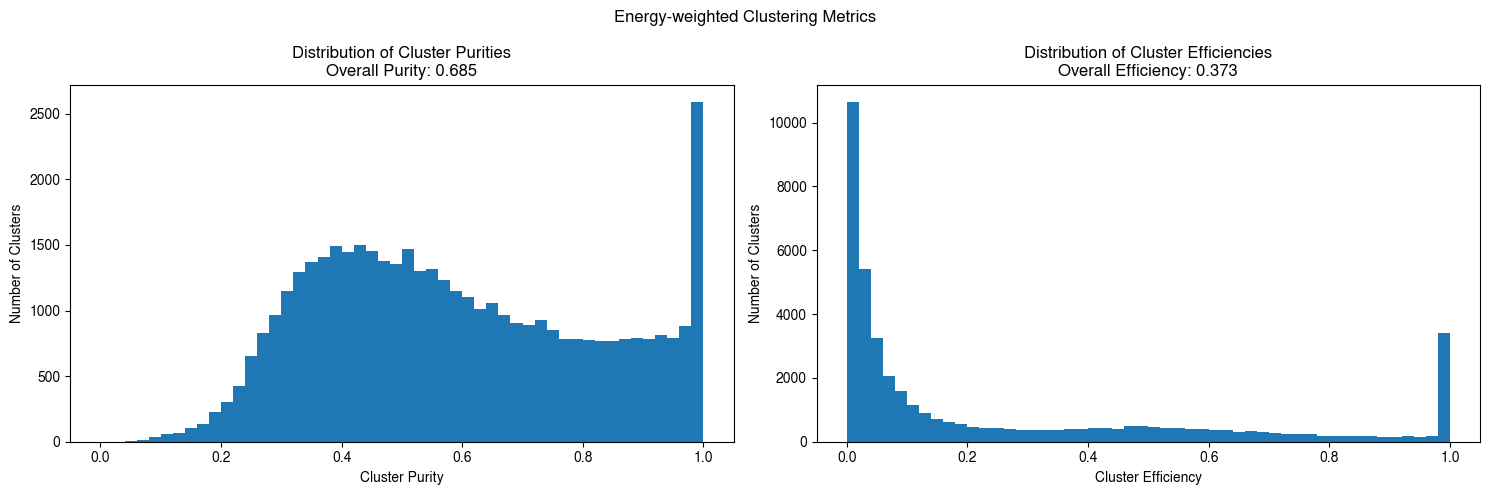

{'purity': 0.6854964, 'efficiency': 0.3725171, 'energy_weighted': True, 'num_clusters': 43152}


In [7]:
metrics_df, overall = evaluate_clustering(mixed_labels_df, energy_weighted=True, label_column='labels_pred', energy_column='energy', particle_id_column='highest_energy_particle_id')

# Plot results
plot_clustering_metrics(metrics_df, overall)

print(overall)

In [8]:
v_score = adjusted_v_score(calo_hits_df['highest_energy_particle_id'], calo_hits_df['labels_pred'], beta=1.0, labels_weight=calo_hits_df['energy'])
v_score


0.9999999999999991

In [9]:
v_score = adjusted_v_score(mixed_labels_df['highest_energy_particle_id'], mixed_labels_df['labels_pred'], beta=1.0, labels_weight=mixed_labels_df['energy'])
v_score

0.41435228329108154

## Try a simple clustering algorithm

In [10]:
from clustering_algorithms import heuristic_energy_clustering

In [11]:
calo_hits_df = heuristic_energy_clustering(calo_hits_df, seed_fraction=0.1)
calo_hits_df

Seeds: 35560
Remaining: 320040
Buliding KDTree
Querying KDTree
Creating cluster assignments


,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector,highest_energy_particle_id,labels_pred,cluster_id
0,19703278443040784,1.836892e-09,35.700001,-1267.550049,357.000000,0,1,1268.052734,1317.348389,-1.542639,1.296366,0.277942,ECalBarrelCollection,96703,0,17701
1,18291088463137206288,6.815690e-06,1343.300049,61.200001,-2820.300049,1,2,1344.693481,3124.466797,0.045528,2.696684,-1.486345,ECalBarrelCollection,96900,1,17897
2,18292495838020694032,7.979669e-06,1333.199951,61.200001,-2794.800049,2,3,1334.603882,3097.107422,0.045872,2.696081,-1.484945,ECalBarrelCollection,96900,1,17897
3,18310510159220439056,6.901636e-07,1173.350220,-519.138733,-2473.500000,3,4,1283.064941,2786.477783,-0.416550,2.663078,-1.410875,ECalBarrelCollection,96897,2,6976
4,18327961818231109648,4.109088e-06,1441.609619,-359.765656,-2152.199951,4,5,1485.822876,2615.269287,-0.244563,2.537356,-1.165847,ECalBarrelCollection,97236,3,33758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355595,168322186405959696,3.216178e-07,354.943817,1323.353149,3049.800049,1632713,1632714,1370.127197,3343.430664,1.308748,0.422231,1.540336,ECalBarrelCollection,1850,43333,6258
355596,163255602465495056,7.675362e-07,396.503204,1317.070801,2958.000000,1632714,1632715,1375.459961,3262.154785,1.278377,0.435255,1.509007,ECalBarrelCollection,1850,43333,1617
355597,163537064557434896,1.236313e-08,418.368774,1329.878174,2963.100098,1632715,1632716,1394.133545,3274.686279,1.266007,0.439769,1.498352,ECalBarrelCollection,1850,43333,1617
355598,167759068948813840,1.204739e-05,538.703430,1247.237427,3034.500000,1632716,1632717,1358.603149,3324.754639,1.163081,0.420955,1.543454,ECalBarrelCollection,1850,43333,5942


Seeds: 3556
Remaining: 352044
Buliding KDTree
Querying KDTree
Creating cluster assignments


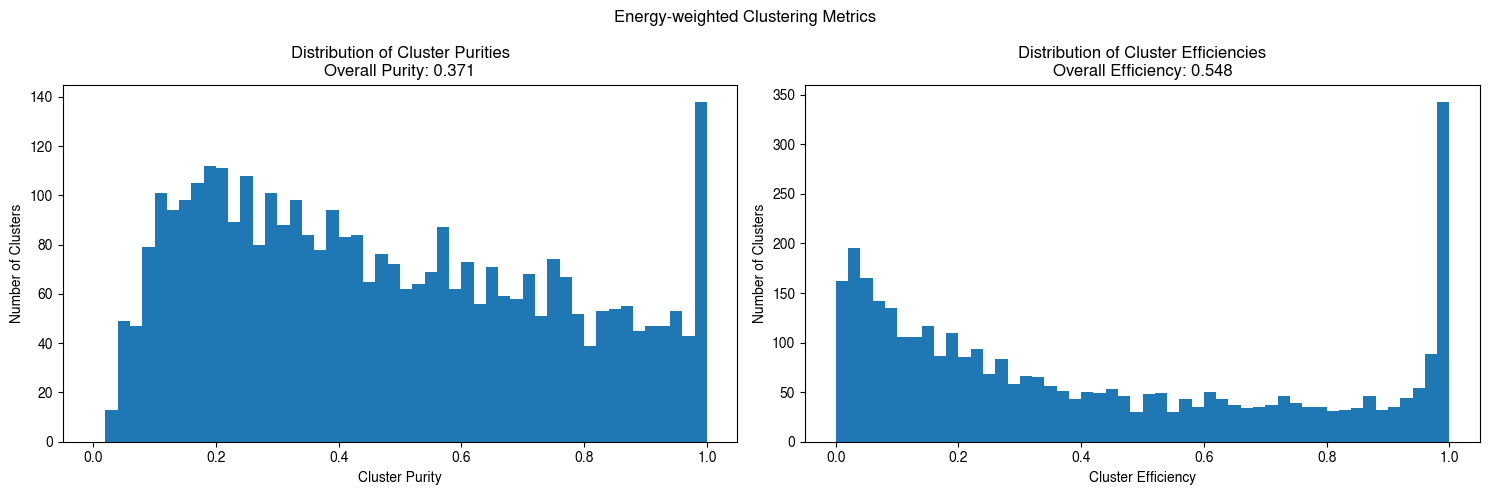

{'purity': 0.3710098, 'efficiency': 0.54787356, 'energy_weighted': True, 'num_clusters': 3556}
Seed fraction: 0.01, V-score: 0.2200425964634818
Seeds: 17780
Remaining: 337820
Buliding KDTree
Querying KDTree
Creating cluster assignments


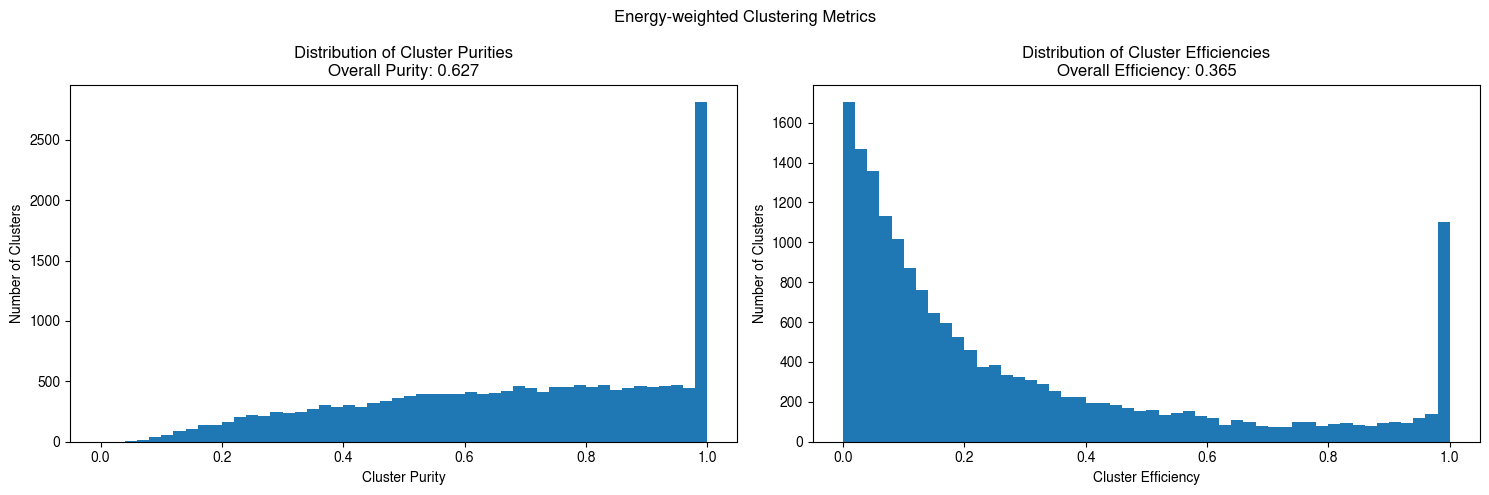

{'purity': 0.6273145, 'efficiency': 0.3652936, 'energy_weighted': True, 'num_clusters': 17780}
Seed fraction: 0.05, V-score: 0.3588017842683122
Seeds: 35560
Remaining: 320040
Buliding KDTree
Querying KDTree
Creating cluster assignments


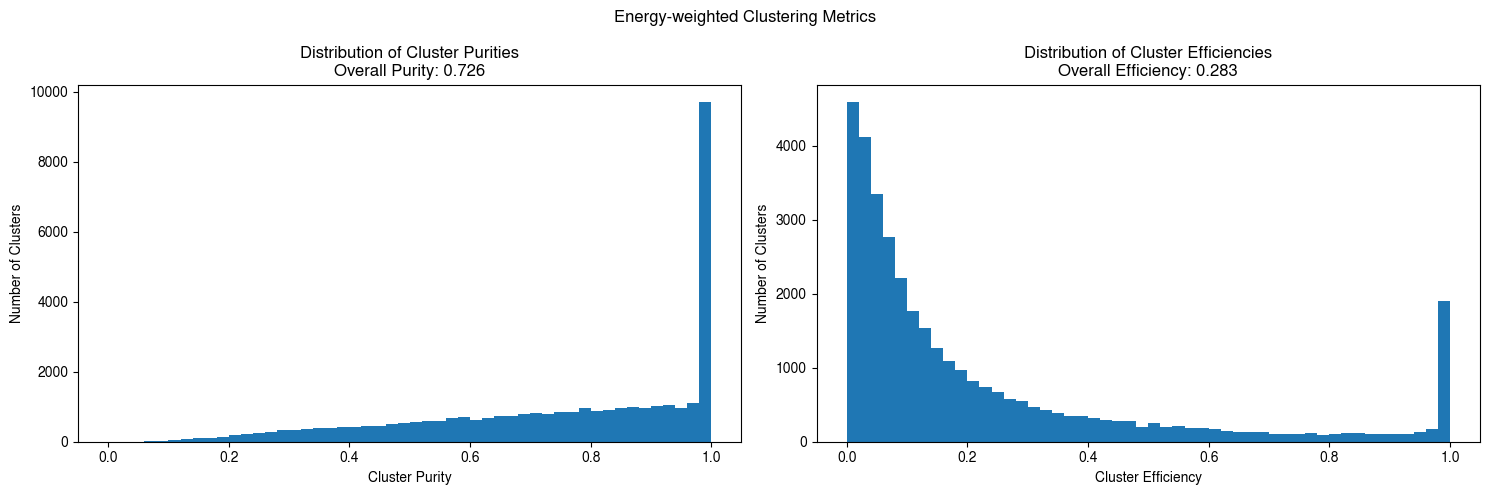

{'purity': 0.7260451, 'efficiency': 0.28321227, 'energy_weighted': True, 'num_clusters': 35560}
Seed fraction: 0.1, V-score: 0.3796209158461392
Seeds: 71120
Remaining: 284480
Buliding KDTree
Querying KDTree
Creating cluster assignments


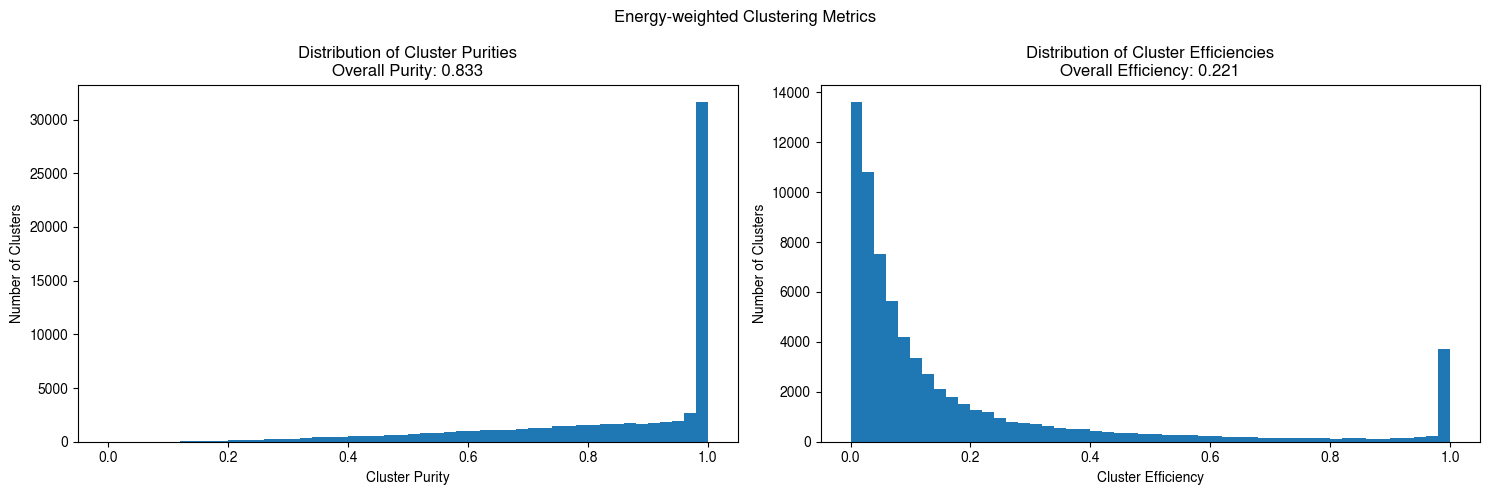

{'purity': 0.8331162, 'efficiency': 0.2214587, 'energy_weighted': True, 'num_clusters': 71120}
Seed fraction: 0.2, V-score: 0.3913378562926837


In [12]:
for seed_fraction in [0.01, 0.05, 0.1, 0.2]:
    calo_hits_df = heuristic_energy_clustering(calo_hits_df, seed_fraction=seed_fraction)
    metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='cluster_id', energy_column='energy', particle_id_column='highest_energy_particle_id')
    plot_clustering_metrics(metrics_df, overall)
    print(overall)
    v_score = adjusted_v_score(calo_hits_df['highest_energy_particle_id'], calo_hits_df['cluster_id'], beta=1.0, labels_weight=calo_hits_df['energy'])
    print(f"Seed fraction: {seed_fraction}, V-score: {v_score}")


## Topoclustering

In [ ]:
# Create configuration
config = TopoClusterConfig(
    seed_threshold=4.0,
    neighbor_threshold=2.0,
    final_threshold=0.0
)

# Initialize clusterer
clusterer = TopoClustering(config)

# Prepare input data
hits_df = pd.DataFrame({
    'x': x_positions,
    'y': y_positions,
    'z': z_positions,
    'energy': energies,
    'noise': noise_levels,
    'layer': layers
})

# Run clustering
result_df = clusterer.cluster(hits_df)

## ML Approaches

### K Means (with cheating!)

In [5]:
from sklearn.cluster import KMeans

number_of_particles = calo_hits_df.highest_energy_particle_id.nunique()

OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.


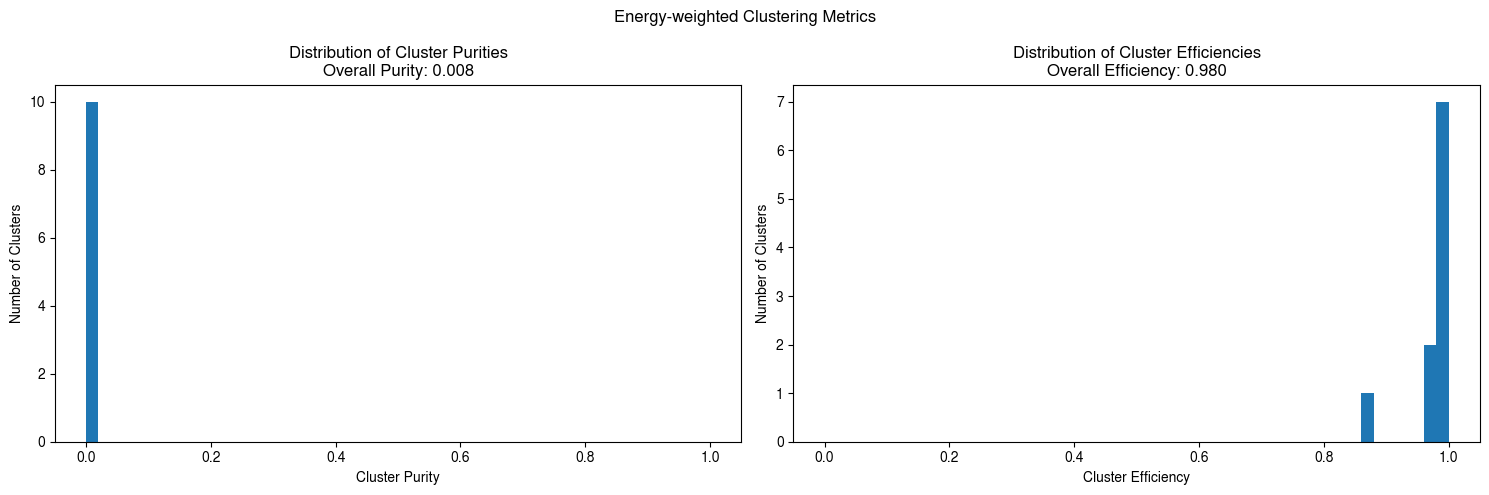

In [6]:

kmeans = KMeans(n_clusters=10)
kmeans.fit(calo_hits_df[['x', 'y', 'z']].values)

calo_hits_df['kmeans_labels'] = kmeans.labels_

metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='kmeans_labels', energy_column='energy', particle_id_column='highest_energy_particle_id')
plot_clustering_metrics(metrics_df, overall)

In [9]:
start_time = time.time()
kmeans = KMeans(n_clusters=50)
kmeans.fit(calo_hits_df[['x', 'y', 'z']].values)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

calo_hits_df['kmeans_labels'] = kmeans.labels_

metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='kmeans_labels', energy_column='energy', particle_id_column='highest_energy_particle_id')
plot_clustering_metrics(metrics_df, overall)

: 

In [26]:
# time

cluster_size_list = [10, 20, 50, 100, 200, 500]

for cluster_size in cluster_size_list:
    start_time = time.time()
    kmeans = KMeans(n_clusters=cluster_size)
    kmeans.fit(calo_hits_df[['x', 'y', 'z']].values)
    end_time = time.time()
    print(f"Time taken: {end_time - start_time} seconds")

    calo_hits_df['kmeans_labels'] = kmeans.labels_

    metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='kmeans_labels', energy_column='energy', particle_id_column='highest_energy_particle_id')
    plot_clustering_metrics(metrics_df, overall)

In [30]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

# Create a clean, C-contiguous copy of the data
data = np.ascontiguousarray(calo_hits_df[['x', 'y', 'z']].values, dtype=np.float32)

# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Starting clustering...")
start_time = time.time()

kmeans = MiniBatchKMeans(
    n_clusters=10000,
    batch_size=1000,
    random_state=42,
    max_iter=100,
    verbose=1,
    tol=1e-4  # Add explicit tolerance
)

# Try with normalized data
kmeans.fit(data_scaled)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['kmeans_labels'] = kmeans.labels_

Starting clustering...
Init 1/1 with method k-means++
Inertia for init 1/1: 52.32097625732422
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 1/35560: mean batch inertia: 0.0018041961193084716
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 2/35560: mean batch inertia: 0.0018298095464706421, ewa inertia: 0.0018298095464706421
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 3/35560: mean batch inertia: 0.001884887933731079, ewa inertia: 0.0018301193228056943
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 4/35560: mean batch inertia: 0.001850316047668457, ewa inertia: 0.0018302329148645624
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 5/35560: mean batch inertia: 0.0019142374992370606, ewa inertia: 0.0018307053802646737
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 6/35560: mean batch inertia: 0.0018179813623428345, ewa inertia: 0.0018306338168105672
[MiniBatchKMeans] Reassign

Cluster sizes:
1317    260
3464    214
9794    208
381     194
2566    192
       ... 
2222      2
6831      2
9725      2
2616      2
8276      1
Name: kmeans_labels, Length: 9502, dtype: int64

Total points: 355600


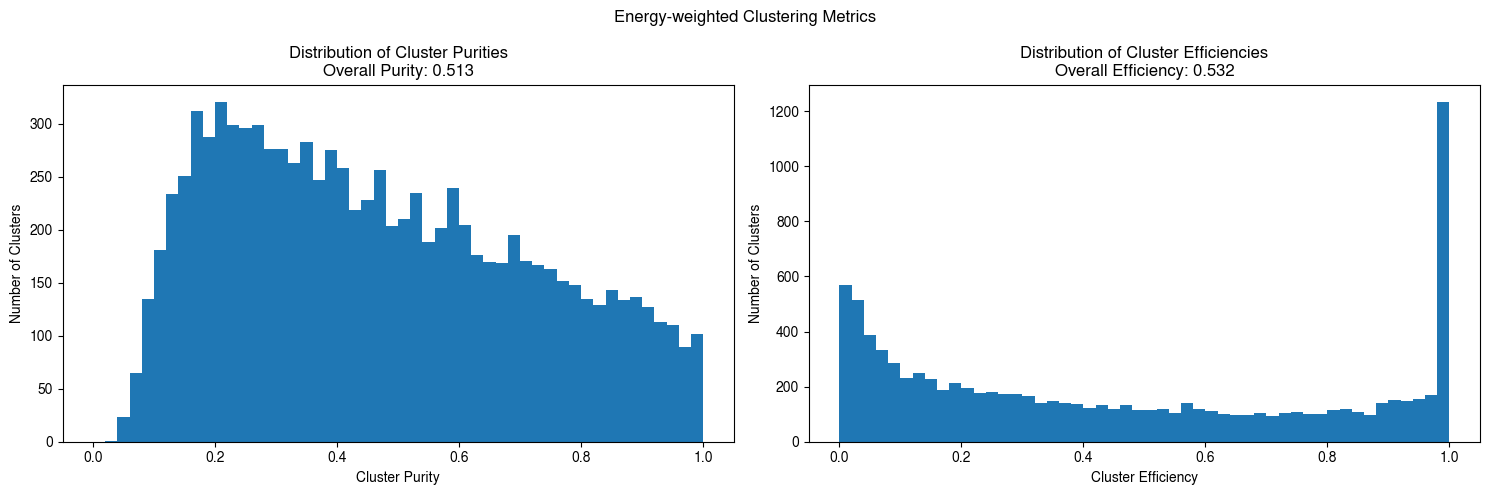

In [31]:
# First look at basic cluster statistics
cluster_sizes = pd.Series(calo_hits_df['kmeans_labels'].value_counts())
print("Cluster sizes:")
print(cluster_sizes)
print("\nTotal points:", cluster_sizes.sum())

# Now evaluate the clustering
metrics_df, overall = evaluate_clustering(
    calo_hits_df, 
    energy_weighted=True, 
    label_column='kmeans_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)

Starting clustering...
Init 1/1 with method k-means++
Inertia for init 1/1: 0.017760716378688812
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 1/35560: mean batch inertia: 3.4834278631024064e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 2/35560: mean batch inertia: 3.085631178691983e-07, ewa inertia: 3.085631178691983e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 3/35560: mean batch inertia: 3.162523207720369e-07, ewa inertia: 3.086063641081169e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 4/35560: mean batch inertia: 2.790456055663526e-07, ewa inertia: 3.0844010609117223e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 5/35560: mean batch inertia: 2.6585772866383194e-07, ewa inertia: 3.0820061082863164e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 6/35560: mean batch inertia: 2.828983997460455e-07, ewa inertia: 3.0805830407987336e-07
[MiniBatchKMeans

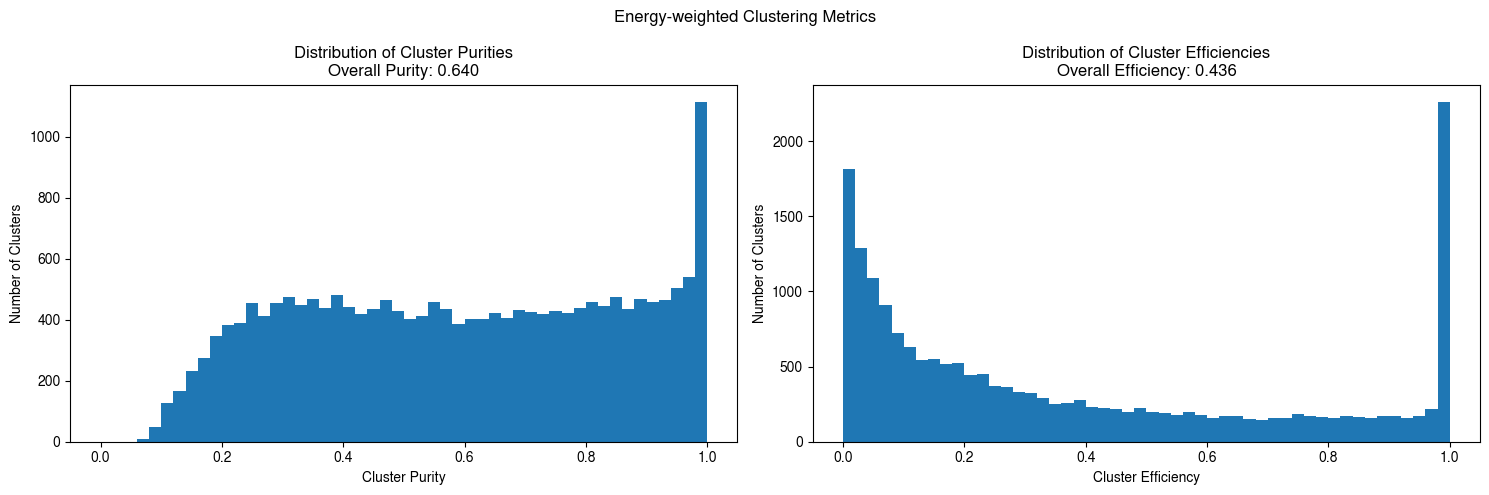

In [39]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import time
import numpy as np

# Create a clean, C-contiguous copy of the data
data = np.ascontiguousarray(calo_hits_df[['x', 'y', 'z']].values, dtype=np.float32)
weights = np.ascontiguousarray(calo_hits_df['energy'].values, dtype=np.float32)

# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Starting clustering...")
start_time = time.time()

kmeans = MiniBatchKMeans(
    n_clusters=20000,
    batch_size=1000,
    random_state=42,
    max_iter=100,
    verbose=1,
    tol=1e-4
)

# Use sample_weight parameter to weight by energy
kmeans.fit(data_scaled, sample_weight=weights)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['kmeans_labels'] = kmeans.labels_

# Evaluate and plot results
metrics_df, overall = evaluate_clustering(
    calo_hits_df, 
    energy_weighted=True,  # Use energy-weighted evaluation
    label_column='kmeans_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)

In [43]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import time
import numpy as np

# Create a clean, C-contiguous copy of the data
data = np.ascontiguousarray(calo_hits_df[['eta', 'phi']].values, dtype=np.float32)
weights = np.ascontiguousarray(calo_hits_df['energy'].values, dtype=np.float32)

# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Starting clustering...")
start_time = time.time()

kmeans = MiniBatchKMeans(
    n_clusters=20000,
    batch_size=1000,
    random_state=42,
    max_iter=100,
    verbose=1,
    tol=1e-4
)

# Use sample_weight parameter to weight by energy
kmeans.fit(data_scaled, sample_weight=weights)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['kmeans_labels'] = kmeans.labels_

# Evaluate and plot results
metrics_df, overall = evaluate_clustering(
    calo_hits_df, 
    energy_weighted=True,  # Use energy-weighted evaluation
    label_column='kmeans_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)

Starting clustering...
Init 1/1 with method k-means++


Cluster sizes:
1317    260
3464    214
9794    208
381     194
2566    192
       ... 
2222      2
6831      2
9725      2
2616      2
8276      1
Name: kmeans_labels, Length: 9502, dtype: int64

Total points: 355600


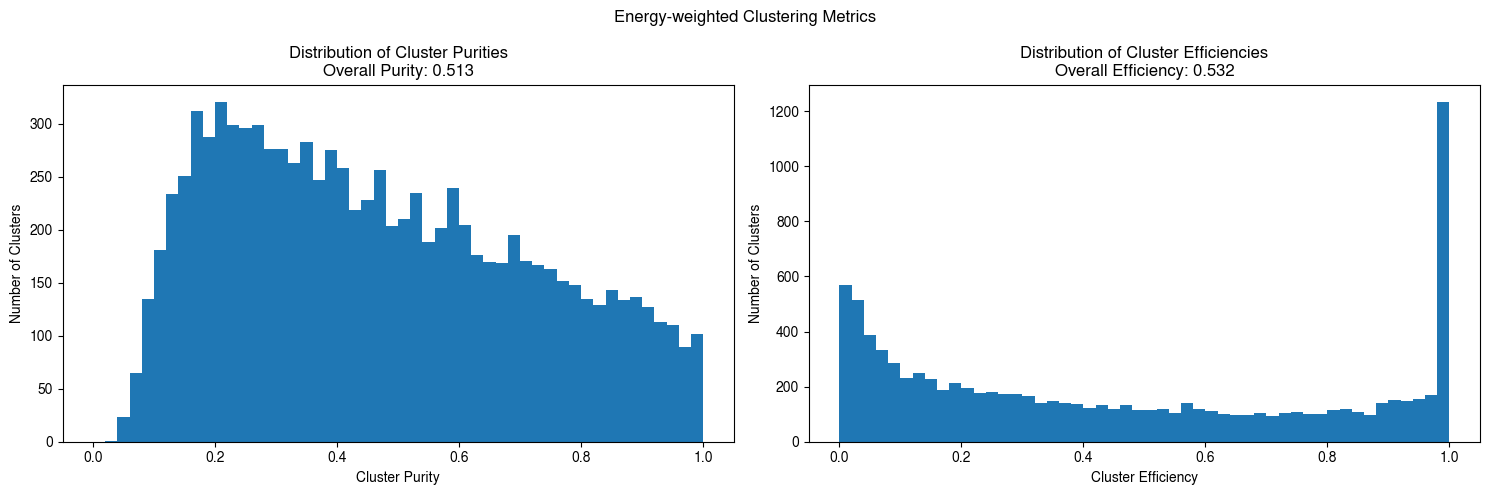

In [ ]:
# First look at basic cluster statistics
cluster_sizes = pd.Series(calo_hits_df['kmeans_labels'].value_counts())
print("Cluster sizes:")
print(cluster_sizes)
print("\nTotal points:", cluster_sizes.sum())

# Now evaluate the clustering
metrics_df, overall = evaluate_clustering(
    calo_hits_df, 
    energy_weighted=True, 
    label_column='kmeans_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)

Starting clustering...
Time taken: 22.32849383354187 seconds
Number of clusters: 6
Number of noise points: 128666 (36.2%)


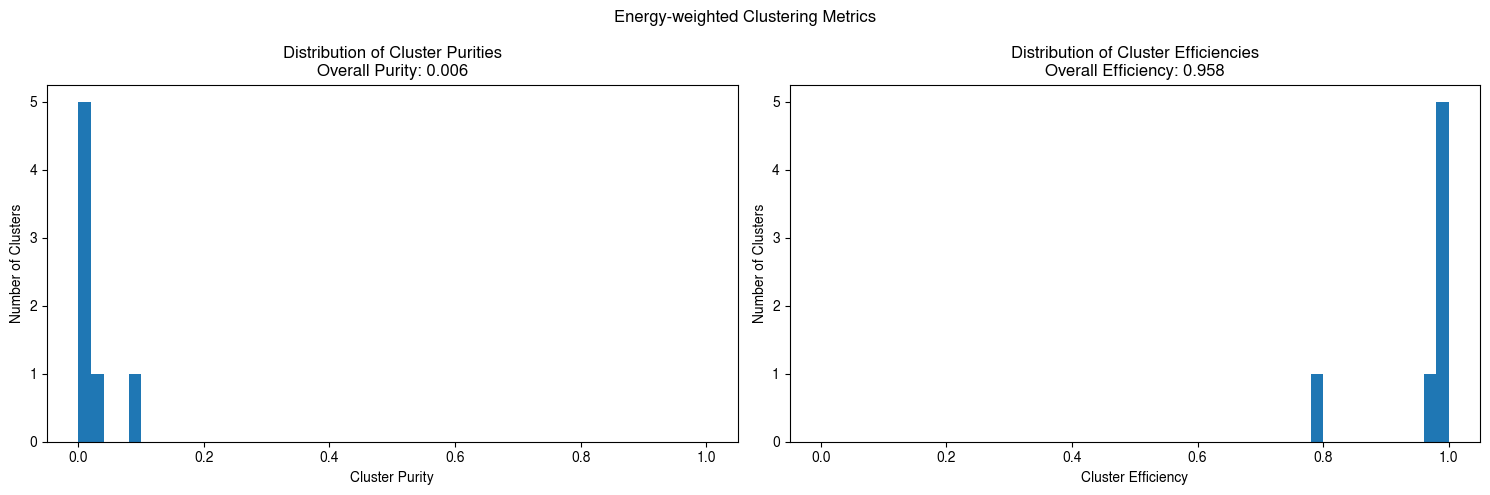

,energy,dominant_particle_id,correct_energy,purity,total_particle_energy,efficiency
dbscan_labels,,,,,,
-1,47.265110,3556405,0.095639,0.002023,0.095940,0.996864
0,25.088465,17111,0.161505,0.006437,0.161507,0.999986
1,27.888899,38941,0.165144,0.005922,0.165767,0.996245
2,25.992064,29912,0.109860,0.004227,0.140711,0.780750
3,16.528809,674620,0.132825,0.008036,0.133295,0.996470
4,1.431719,1435500,0.042440,0.029643,0.042440,1.000000
5,1.898227,53489,0.159864,0.084218,0.165099,0.968294


In [54]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

# Prepare the data
data = np.ascontiguousarray(calo_hits_df[['eta', 'phi']].values, dtype=np.float32)
weights = np.ascontiguousarray(calo_hits_df['energy'].values, dtype=np.float32)

# Normalize spatial coordinates
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Starting clustering...")
start_time = time.time()

# DBSCAN with energy weights
dbscan = DBSCAN(
    eps=0.14,
    min_samples=1,
    metric='euclidean',
    n_jobs=-1
)

# Fit with sample_weight parameter
dbscan.fit(data_scaled, sample_weight=weights)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['dbscan_labels'] = dbscan.labels_

# Print some basic clustering info
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = list(dbscan.labels_).count(-1)
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(data)*100:.1f}%)")

# Evaluate clustering (excluding noise points)
# Create a copy of the filtered DataFrame and reset its index
# clustered_df = calo_hits_df[calo_hits_df['dbscan_labels'] >= 0].copy().reset_index(drop=True)
clustered_df = calo_hits_df.copy().reset_index(drop=True)

metrics_df, overall = evaluate_clustering(
    clustered_df,
    energy_weighted=True,
    label_column='dbscan_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)
metrics_df

In [12]:
from sklearn.cluster import MeanShift
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

# Prepare the data
data = np.ascontiguousarray(calo_hits_df[['eta', 'phi']].values, dtype=np.float32)
weights = np.ascontiguousarray(calo_hits_df['energy'].values, dtype=np.float32)

# Normalize spatial coordinates
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = data_scaled[:50000]
weights = weights[:50000]

print("Starting clustering...")
start_time = time.time()

# MeanShift clustering with energy weights
meanshift = MeanShift(
    bandwidth=0.1,  # Adjust bandwidth parameter as needed
    n_jobs=4
)

# Fit with sample_weight parameter
meanshift.fit(data_scaled)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['dbscan_labels'] = meanshift.labels_

# Print some basic clustering info
n_clusters = len(set(meanshift.labels_))
print(f"Number of clusters: {n_clusters}")

# Create a copy of the DataFrame and reset its index
clustered_df = calo_hits_df.copy().reset_index(drop=True)

metrics_df, overall = evaluate_clustering(
    clustered_df,
    energy_weighted=True,
    label_column='dbscan_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)
metrics_df

Starting clustering...
Time taken: 55.31054496765137 seconds


ValueError: Length of values (50000) does not match length of index (355600)

In [46]:
metrics_df

,energy,dominant_particle_id,correct_energy,purity,total_particle_energy,efficiency
dbscan_labels,,,,,,
0,5.421346,4108312,0.921536,0.169983,0.921536,1.000000
1,5.171498,1980,1.271938,0.245952,1.272113,0.999862
2,3.242600,4049239,0.814365,0.251146,0.814603,0.999708


In [48]:
calo_hits_df.energy.sum()

146.09329